In [1]:
# Number of free parameters per model
# Format: model_label: (per_voxel_free, n_shared, description)
n_free_pars = {
    -1: 1,   # Mean intercept only
    0:  4,   # mu, sd, amplitude, baseline (delta_wide=1, fixed)
    1:  4,   # mu, sd, amplitude, baseline (delta_wide=2, fixed)
    2:  4+1, # mu, sd, amplitude, baseline + 1 shared (delta_wide)
    3:  6,   # mu, delta_wide, lower_bound_range, sd, amplitude, baseline
    4:  4,   # mu, sd, amplitude, baseline (identity below range, delta_wide=2 fixed)
    5:  4+1, # mu, sd, amplitude, baseline + 1 shared (delta_wide)
    6:  6+1, # mu, delta_wide, lower_bound_range, sd, amplitude, baseline + 1 shared (alpha)
    7:  4+1, # mu, sd, amplitude, baseline + 1 shared (alpha)
    8:  4+2, # mu, sd, amplitude, baseline + 2 shared (alpha, delta_wide)
    9:  5,   # mu, delta_wide, lower_bound_range, sd, amplitude (baseline=0 fixed)
    10: 6,   # mu, delta_wide, lower_bound_range, sd, amplitude_narrow, amplitude_wide (baseline=0)
    11: 7,   # mu, delta_wide, sd, amplitude_narrow, amplitude_wide, baseline, baseline_ratio
    12: 6,   # mu, sd, amplitude_narrow, amplitude_wide, baseline_narrow, baseline_wide
    13: 5+1, # mu, sd, amplitude_narrow, amplitude_wide, baseline + 1 shared (baseline_ratio)
    14: 5,   # mu, sd_narrow, sd_wide, amplitude, baseline
    15: 4+1, # mu, baseline, sd_narrow, amplitude + 1 shared (sd_wide_scale)
    16: 4+3, # mu, baseline, sd, amplitude_narrow + 3 shared (amplitude_alpha, amplitude_beta, baseline_ratio)
    17: 4+4, # mu, baseline, sd_narrow, amplitude_narrow + 4 shared (sd_wide_scale, amplitude_alpha, amplitude_beta, baseline_ratio)
    18: 4+2, # mu, baseline, sd_narrow, amplitude + 2 shared (delta_wide, sd_wide_scale)
    19: 4+4, # mu, baseline, sd, amplitude_narrow + 4 shared (delta_wide, amplitude_alpha, amplitude_beta, baseline_ratio)
    20: 4+5, # mu, baseline, sd_narrow, amplitude_narrow + 5 shared (delta_wide, sd_wide_scale, amplitude_alpha, amplitude_beta, baseline_ratio)
    21: 4+2, # mu, baseline, sd, amplitude_narrow + 2 shared (amplitude_alpha, amplitude_beta)
    22: 4+3, # mu, baseline, sd_narrow, amplitude_narrow + 3 shared (sd_wide_scale, amplitude_alpha, amplitude_beta)
    23: 4+3, # mu, baseline, sd, amplitude_narrow + 3 shared (delta_wide, amplitude_alpha, amplitude_beta)
    24: 4+4, # mu, baseline, sd_narrow, amplitude_narrow + 4 shared (delta_wide, sd_wide_scale, amplitude_alpha, amplitude_beta)
    25: 4,   # mu, baseline, sd_narrow, amplitude (delta_wide, sd_wide_scale fixed)
    26: 4+1, # mu, baseline, sd_narrow, amplitude + 1 shared (sd_wide_scale); natural SD
    27: 4,   # mu, baseline, sd_narrow, amplitude (sd_wide_scale=2 fixed); natural SD
    28: 4+1, # mu, baseline, sd_narrow, amplitude + 1 shared (sd_wide_scale); FWHM
    29: 4,   # mu, baseline, sd_narrow, amplitude (sd_wide_scale=2 fixed); FWHM
    30: 5,   # mu, baseline, sd_narrow, sd_wide_scale, amplitude (sd_wide_scale free per voxel!); FWHM
    31: 4,   # mu, baseline, sd_narrow, amplitude (delta_wide, sd_wide_scale fixed)
    32: 5,   # mu, baseline, sd_narrow, amplitude_narrow, amplitude_beta (amplitude_alpha=0 fixed)
    33: 4+1, # mu, baseline, sd_narrow, amplitude_narrow + 1 shared (amplitude_beta)
    34: 6,   # mu, lower_bound_range, baseline, sd, amplitude_narrow, amplitude_beta (note: fixed_pars REPLACES generic rules)
    35: 5+2, # mu, lower_bound_range, baseline, sd, amplitude_narrow + 2 shared (amplitude_alpha, amplitude_beta)
}
# Models >100 (e.g., 115-145): 5 per voxel (mu, delta_wide, baseline, sd_narrow, amplitude); sd_wide_scale fixed

In [2]:
import pandas as pd
import re
from pathlib import Path
import numpy as np

bids_folder = Path('/data/ds-neuralpriors')


# Find all likelihood files
likelihood_files = list((bids_folder / "derivatives" / "encoding_models").glob("**/*desc-likelihood_roi-*.tsv"))

# /data/ds-neuralpriors/derivatives/encoding_models/model15.smoothed/sub-04/func/sub-04_desc-likelihood_roi-NPCr.tsv

reg = re.compile(r"model(-?\d+)(\.smoothed)?(\.fit_responses)?/sub-(\d+)/func/sub-\d+_desc-likelihood_roi-(\w+).tsv")
    
records = []
for f in likelihood_files:
    match = reg.search(str(f))

    ll = pd.read_csv(f, sep="\t")
    ll["model"] = int(match.group(1))
    ll["smoothed"] = bool(match.group(2))
    ll["fit_responses"] = bool(match.group(3))
    ll["subject"] = int(match.group(4))
    ll["roi"] = match.group(5)

    ll['voxel'] = np.arange(len(ll))
    records.append(ll)

df = pd.concat(records, ignore_index=True)
df = df.set_index(['model', 'smoothed', 'fit_responses', 'subject', 'roi', 'voxel']).droplevel('roi')


df.to_csv(bids_folder / "derivatives" / "encoding_models" / "all_likelihoods.tsv", sep='\t')

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 7.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 21.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 30.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 45.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, Us

Text(0.5, 1.02, 'Proportion of Winning Models by Subject and Fit Responses')

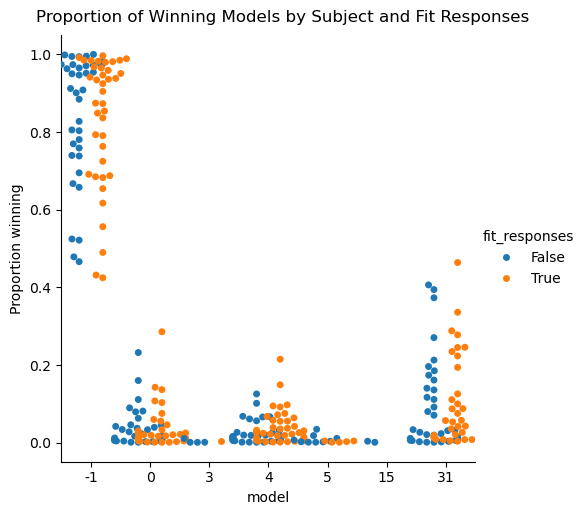

In [3]:
import numpy as np

n_obs = 480  # 240 trials per session × 2 sessions

# Map n_free_pars to the dataframe
df['k'] = df.index.get_level_values("model").map(n_free_pars)

# BIC = k * ln(n) - 2 * loglikelihood
df['bic'] = df['k'] * np.log(n_obs) - 2 * df['loglikelihood']


winning_models = df.unstack('model')['bic'].idxmin(axis=1)


# Get the proportion of winning models for each subject and plot the results. Use seaborn
import seaborn as sns
import matplotlib.pyplot as plt
winning_models = winning_models.to_frame('model')


counts = winning_models.groupby(['subject', 'fit_responses'])['model'].value_counts(normalize=True).to_frame("Proportion winning")

g = sns.catplot(data=counts.reset_index(), x='model', y='Proportion winning', kind='swarm', hue='fit_responses', dodge=True)

g.fig.suptitle('Proportion of Winning Models by Subject and Fit Responses', y=1.02)

Text(0.5, 1.02, 'Average BIC by Subject and Fit Responses (no_filtering)')

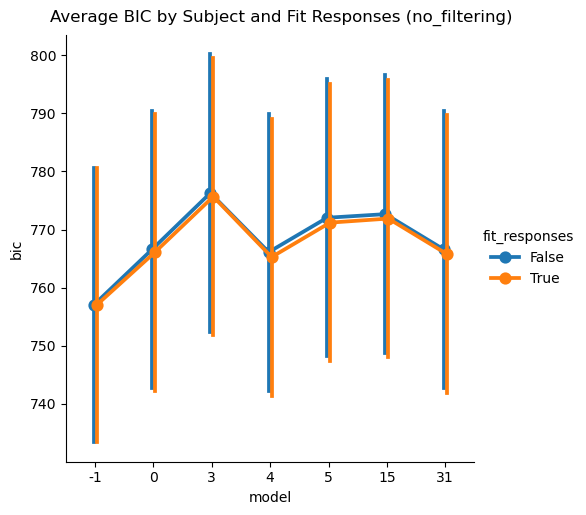

In [4]:
summed_bic = df.groupby(['subject', 'model', 'fit_responses'])['bic'].mean()

g = sns.catplot(data=summed_bic.reset_index(), x='model', y='bic', kind='point', hue='fit_responses', dodge=True, errorbar='se')

g.fig.suptitle('Average BIC by Subject and Fit Responses (no_filtering)', y=1.02)

AttributeError: 'FacetGrid' object has no attribute 'suptitle'

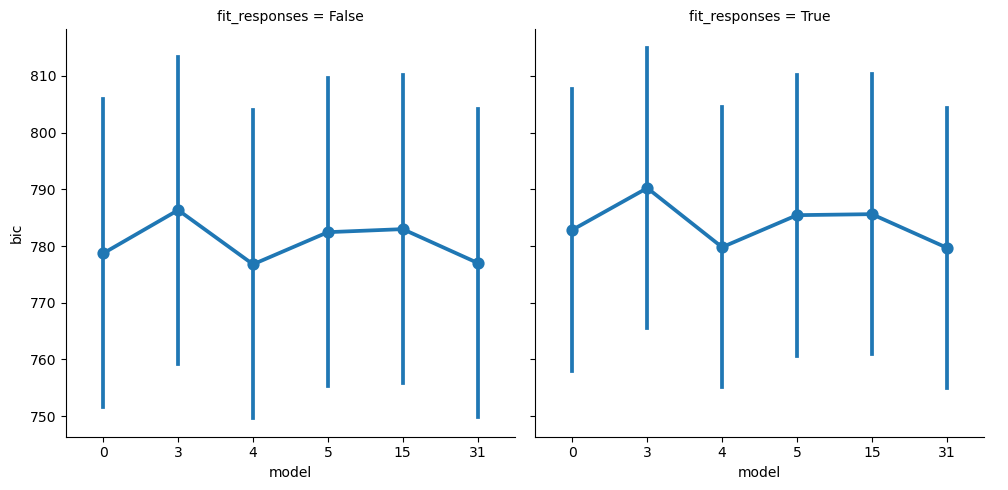

In [30]:
tmp = df['bic'].unstack('model')
tmp = tmp[tmp.idxmin(axis=1) != - 1].stack()

tmp = tmp.drop(-1, level='model')

tmp = tmp.groupby(['subject', 'model', 'fit_responses']).mean()

g = sns.catplot(data=tmp.to_frame("bic").reset_index(), x='model', y='bic', kind='point', col='fit_responses', errorbar='se')

g.suptitle('Average BIC by Subject and Fit Responses (no-signal voxels filtered out)', y=1.02)

Text(0.5, 1.02, 'Average $\\delta$ BIC (compared to no-shift model) by Subject and Fit Responses (Filtered)')

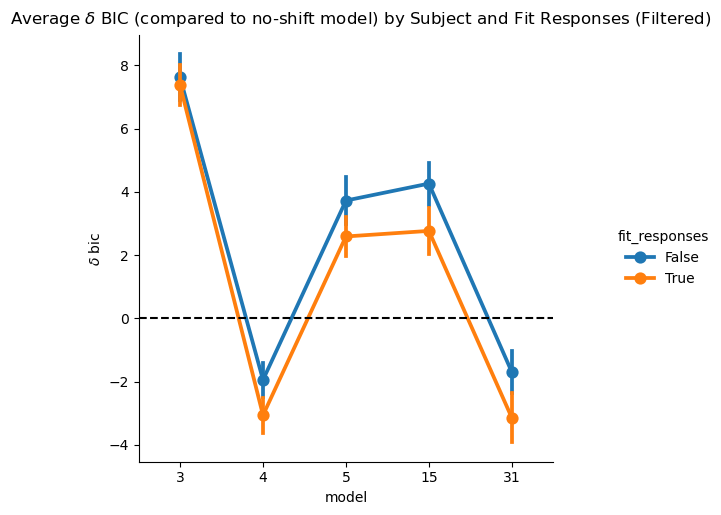

In [32]:
tmp2 = tmp.unstack('model')
tmp2 -= tmp2[0].values[:, np.newaxis]


g = sns.catplot(tmp2.stack().drop(0, level='model').to_frame("$\delta$ bic"), x='model', y='$\delta$ bic', hue='fit_responses', kind='point', errorbar='se')
plt.axhline(0.0, c='k', ls='--')

g.fig.suptitle('Average $\delta$ BIC (compared to no-shift model) by Subject and Fit Responses (Filtered)', y=1.02)

In [6]:
import pingouin as pg

pg.ttest(tmp.xs(True, level='fit_responses').unstack('model')[0], tmp.xs(True, level='fit_responses').unstack('model')[4], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.5746,38,two-sided,0.000002,"[1.95, 4.17]",0.019756,8266.961,0.051659


In [11]:
pg.ttest(tmp.xs(True, level='fit_responses').unstack('model')[0], tmp.xs(True, level='fit_responses').unstack('model')[31], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,4.056469,38,two-sided,0.000239,"[1.57, 4.71]",0.020329,111.166,0.051757


In [12]:
pg.ttest(tmp.xs(True, level='fit_responses').unstack('model')[4], tmp.xs(True, level='fit_responses').unstack('model')[31], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.20569,38,two-sided,0.838131,"[-0.74, 0.91]",0.000544,0.176,0.050001
